# Exploring some properties of the fill-spill-merge algorithm

Key concepts:
- fill-spill-merge is a meltwater routing algorithm that takes a elevation and melt fields as inputs and outputs a water depth field:
is the output of the fill-spill-merge funciton $F$:

$$
F(d(x,y), m(x,y)) = w(x,y)
$$

where $d(x,y)$ if the elevation, $m(x,y)$ is the melt, and $w(x,y)$ is the water depth.

- a property [1] of $F$ is that:

$$
F(d, 2m) = F(d + F(d, m), m) + F(d, m),
$$

i.e. if you compute water depth and use it to modify the elevation, then compute water depth again, you get an equivelent answer as if you had just doubled the melt in the first place.

- a more useful property [2] is

$$
F(d, m) = F(d, F(d, m)),
$$

i.e. if you compute water depth for a given $d$ and $m$, then input this water depth as the melt for a second call to $F$, you get the same answer as if you had just called $F$ once. This is useful because you can in theory use the same $d$ for every call to $F$, which saves a lot of computation time because the algorythm has two stages, one is computing the 'depression heirachy' and the other is partitioning the water between the derpressions. The latter is much faster than the former. 

- you can consider $F$ defined for a given, unchanging $d$, which we'll call $F_d$:

$$
F_d(m) = w
$$

- it follows that [3]
  
$$ 
F_d(F_d(m)) = F_d(m) 
$$

- another property [4] is that $F$ is not in general linear, i.e.
  
$$
F_d(m_1 + m_2) \neq F_d(m_1) + F_d(m_2)
$$

- I have implmented a python wrapper for the fill-spill-merge algorithm that lives in a separate repo called fill-spill-merge. This uses xarrays as inputs and outputs. 

In [1]:
import sys
sys.path.insert(0, "/Users/jkingslake/Documents/science/meltwater_routing/fsm_pywrapper/fillspillmerge")

from fillspillmerge import fill_spill_merge
import pdemtools as pdt
import rioxarray
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np


In [132]:
d = rioxarray.open_rasterio('Nivlisen_32m_REMA.tif').squeeze()
coarsen_factor = 4
d = d.coarsen(x=coarsen_factor, y=coarsen_factor, boundary='trim').mean()
ocean_value = 0.0

d[0:1,:] = ocean_value 
d[-1:,:] = ocean_value
d[:,0:1] = ocean_value
d[:,-1:] = ocean_value
_, hier = fill_spill_merge(
    topography=d,
    ocean_level=ocean_value,
    return_hierarchy=True,
)

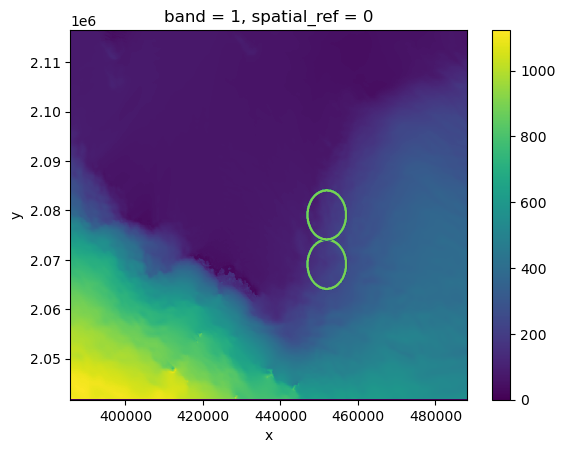

In [133]:
center_x = d.x.mean().values +15000
center_y = d.y.mean().values - 10000

def m(center_x=center_x, center_y=center_y, region_size=5000):
    circular_mask = (np.abs(d.x - center_x)**2 + (np.abs(d.y - center_y)**2) < region_size**2).transpose(*d.dims)
    return xr.where(circular_mask, 1.0, 0.0)

d.plot()
m1 = m()
m2 = m(center_y = center_y + 10000)
m1.plot.contour()
m2.plot.contour()

In [134]:
def F(dem, melt):
    return fill_spill_merge(topography=dem, wtd = melt, ocean_level=ocean_value)

## Numerical verification of property [1]

$$
F(d, 2m) = F(d + F(d, m), m) + F(d, m),
$$

In [137]:
(F(d,2*m1)).mean().values, (F(d + F(d, m1), m1) + F(d, m1)).mean().values

(array(0.02047863), array(0.02047863))

## Numerical verification of property [2]
$$
F(d, m) = F(d, F(d, m)),
$$

In [ ]:
F(d,m1).mean().values,  F(d, F(d, m1)).mean().values

(array(0.01023932), array(0.01023932))

## Numerical verification of property [3]

$$ 
F_d(F_d(m)) = F_d(m) 
$$

[2] motivates efining $F_d$ as a function of $m$ for a given, unchanging $d$.

In [140]:
def F_d(melt):
    return fill_spill_merge(wtd=melt, hierarchy=hier)

In [141]:
assert F_d(F_d(m1)).mean().values == F_d(m1).mean().values

## Numerical verification of property [4]

$$
F_d(m_1 + m_2) \neq F_d(m_1) + F_d(m_2)
$$


In [142]:
F_d(m1 + m2).mean().values, (F_d(m1) + F_d(m2)).mean().values

(array(0.02047009), array(0.02047009))

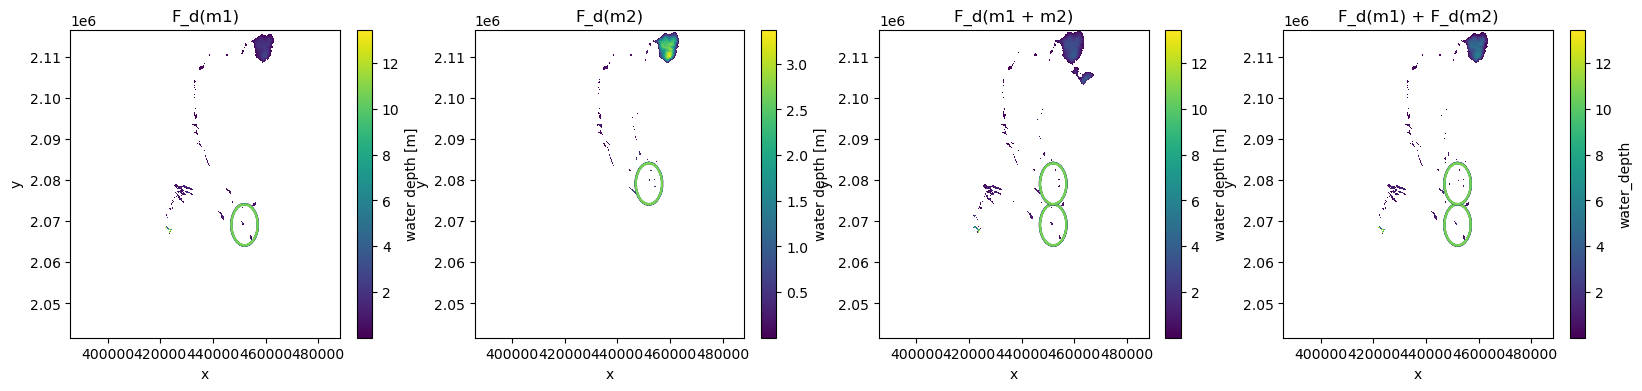

In [143]:
def melt_plot(w, ax=None):
    w.where(w>0).plot(ax=ax)
    return ax

fig, axs = plt.subplots(1, 4, figsize=(20, 4))

melt_plot(F_d(m1), ax=axs[0])
m1.plot.contour(ax=axs[0])
axs[0].set_title('F_d(m1)')

melt_plot(F_d(m2), ax=axs[1])
m2.plot.contour(ax=axs[1])
axs[1].set_title('F_d(m2)')
melt_plot(F_d(m1 + m2), ax=axs[2])
m1.plot.contour(ax=axs[2])
m2.plot.contour(ax=axs[2])
axs[2].set_title('F_d(m1 + m2)');
melt_plot(F_d(m1) + F_d(m2), ax=axs[3])
m1.plot.contour(ax=axs[3])
m2.plot.contour(ax=axs[3])
axs[3].set_title('F_d(m1) + F_d(m2)');